# Week 6 Student Worksheet: Spatial Prediction Shootout

## Traditional Stats vs. Machine Learning: Filling the Gaps

> *"Kriging tells you where it's uncertain. ML just says 'trust me.'"*

### Today's Mission

Transform Week 5's discrete rainfall stations into **continuous rainfall surfaces** using **two fundamentally different approaches**:

1. **Kriging (Statistical)** — uses spatial correlation + provides uncertainty
2. **Random Forest (ML)** — uses data patterns + easily adds features

Then compare them head-to-head with two simpler methods (Nearest Neighbor, IDW) and determine which gives the Commander more actionable intelligence.

> Fill in the code cells marked with `# YOUR CODE HERE`. Use AI tools strategically — but understand every line you write.

In [1]:
%pip install pykrige scikit-learn rasterio rasterstats scipy --quiet


Note: you may need to restart the kernel to use updated packages.


---

## Cell [1]: Environment Setup & Data Loading (Slide 2)

Load the Fung-wong typhoon data and filter to the study area. Reuse your Week 5 `parse_rainfall_json()` function.

**AI Prompt Suggestion**:
```
I need to load fungwong_202511.json and parse it into a GeoDataFrame using
my Week 5 parse_rainfall_json() function. Then filter to 花蓮縣 and 宜蘭縣,
remove -998/zero rain stations, and convert to EPSG:3826.
Show me the top 5 stations by rain_1hr.
```

In [2]:
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
from pathlib import Path
from IPython.display import display
from shapely.geometry import Point

warnings.filterwarnings('ignore')


def _clean_precip(value):
    try:
        value = float(value)
    except (TypeError, ValueError):
        return np.nan
    return np.nan if value <= -998 else value


def normalize_cwa_json(raw_json):
    stations = raw_json.get('records', {}).get('Station', [])
    rows = []
    for station in stations:
        geo = station.get('GeoInfo', {})
        coords = geo.get('Coordinates', [])
        coord = coords[0] if coords else {}
        rainfall = station.get('RainfallElement', {})
        rows.append({
            'station_name': station.get('StationName'),
            'station_id': station.get('StationId'),
            'obs_time': station.get('ObsTime', {}).get('DateTime'),
            'county': geo.get('CountyName'),
            'town': geo.get('TownName'),
            'lon': coord.get('StationLongitude'),
            'lat': coord.get('StationLatitude'),
            'rain_10min': _clean_precip(rainfall.get('Past10Min', {}).get('Precipitation')),
            'rain_1hr': _clean_precip(rainfall.get('Past1hr', {}).get('Precipitation')),
            'rain_3hr': _clean_precip(rainfall.get('Past3hr', {}).get('Precipitation')),
            'rain_6hr': _clean_precip(rainfall.get('Past6hr', {}).get('Precipitation')),
            'rain_12hr': _clean_precip(rainfall.get('Past12hr', {}).get('Precipitation')),
            'rain_24hr': _clean_precip(rainfall.get('Past24hr', {}).get('Precipitation')),
        })
    return pd.DataFrame(rows)


def parse_rainfall_json(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        raw_json = json.load(f)

    df = normalize_cwa_json(raw_json)
    df = df.dropna(subset=['lon', 'lat']).copy()
    geometry = [Point(lon, lat) for lon, lat in zip(df['lon'], df['lat'])]
    return gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')


STUDY_COUNTIES = ['花蓮縣', '宜蘭縣']

rainfall_candidates = [
    Path('data/scenarios/fungwong_202511.json'),
    Path('fungwong_202511.json'),
]
rainfall_path = next((p for p in rainfall_candidates if p.exists()), None)
if rainfall_path is None:
    raise FileNotFoundError('Could not find fungwong_202511.json in the expected paths.')

rain_gdf = parse_rainfall_json(rainfall_path)
study_rain = rain_gdf[rain_gdf['county'].isin(STUDY_COUNTIES)].copy()
study_rain = study_rain[study_rain['rain_1hr'] > 0].copy()
study_rain_3826 = study_rain.to_crs(epsg=3826)
study_rain_3826 = study_rain_3826.sort_values('rain_1hr', ascending=False).reset_index(drop=True)

x = study_rain_3826.geometry.x.to_numpy()
y = study_rain_3826.geometry.y.to_numpy()
z = study_rain_3826['rain_1hr'].to_numpy(dtype=float)

print(f"Loaded rainfall file: {rainfall_path}")
print(f"Study area stations (rain > 0): {len(study_rain_3826)}")
print(f"CRS: {study_rain_3826.crs}")
print("\nTop 5 stations:")
print(
    study_rain_3826.nlargest(5, 'rain_1hr')[['station_name', 'county', 'rain_1hr']]
    .to_string(index=False)
)


Loaded rainfall file: fungwong_202511.json
Study area stations (rain > 0): 89
CRS: EPSG:3826

Top 5 stations:
station_name county  rain_1hr
          蘇澳    宜蘭縣     130.5
     國五S047K    宜蘭縣      80.5
          五結    宜蘭縣      71.0
          冬山    宜蘭縣      61.5
     國五S041K    宜蘭縣      46.0


---

## Cell [2a]: Variogram — First Attempt (Naive)

Try running Kriging directly on the raw rainfall data. **Don't worry if it looks bad — that's the point.**

**Key Concepts** (will make sense after you see the result):
- **Nugget**: How noisy is each measurement?
- **Sill**: What's the maximum difference between stations?
- **Range**: How far apart do stations need to be before they stop "knowing about each other"?

**CRS Warning**: The x, y arrays MUST be in EPSG:3826 (meters). Using lat/lon will give wrong results.

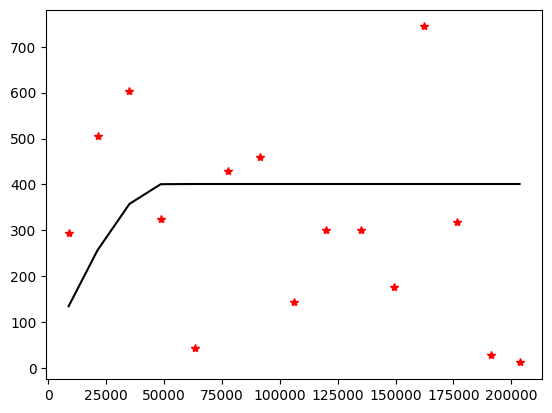

Sill:   400.9
Range:  50000 m (50.0 km)
Nugget: 40.1

⚠️ Look at the plot — do the dots follow the curve?


In [3]:
from pykrige.ok import OrdinaryKriging
from pykrige.variogram_models import spherical_variogram_model, exponential_variogram_model

# 🔴 First attempt: run Kriging on raw rainfall data
initial_sill = float(z.var())
initial_range = 50000.0
initial_nugget = float(z.var() * 0.1)

OK_naive = OrdinaryKriging(
    x,
    y,
    z,
    variogram_model='spherical',
    verbose=False,
    enable_plotting=True,
    nlags=15,
    variogram_parameters={
        'sill': initial_sill,
        'range': initial_range,
        'nugget': initial_nugget,
    },
)

params = OK_naive.variogram_model_parameters
naive_sill = float(params[0] + params[2])
print(f"Sill:   {naive_sill:.1f}")
print(f"Range:  {params[1]:.0f} m ({params[1] / 1000:.1f} km)")
print(f"Nugget: {params[2]:.1f}")
print("\n⚠️ Look at the plot — do the dots follow the curve?")


## Cell [2b]: Why Did It Fail? — Look at the Histogram

The variogram looked bad. Before blaming the tool, **look at your data**.

Plot a histogram of the rainfall values. What do you see?

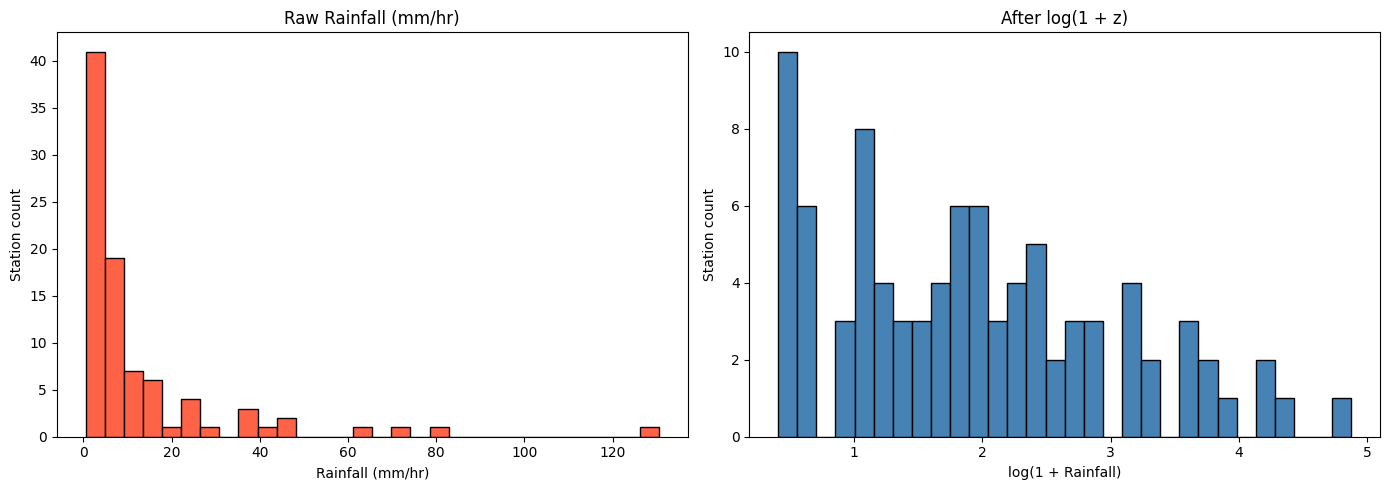

Left: most stations have lower rainfall, but a few extreme values stretch the tail.
Those large values dominate the semivariance and make the raw variogram unstable.
Right: after log-transform, the distribution is more balanced for Kriging.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(z, bins=30, color='tomato', edgecolor='black')
axes[0].set_title('Raw Rainfall (mm/hr)')
axes[0].set_xlabel('Rainfall (mm/hr)')
axes[0].set_ylabel('Station count')

z_log = np.log1p(z)
axes[1].hist(z_log, bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('After log(1 + z)')
axes[1].set_xlabel('log(1 + Rainfall)')
axes[1].set_ylabel('Station count')

plt.tight_layout()
plt.show()

print("Left: most stations have lower rainfall, but a few extreme values stretch the tail.")
print("Those large values dominate the semivariance and make the raw variogram unstable.")
print("Right: after log-transform, the distribution is more balanced for Kriging.")


## Cell [2c]: Variogram — Second Attempt (with Log-Transform)

Now redo the variogram using the log-transformed data. Compare this plot with Cell [2a] — it should be much better.

**Rule of thumb**: If your histogram has a long tail to the right, apply `np.log1p(z)` before Kriging, then use `np.expm1()` to convert back after prediction.

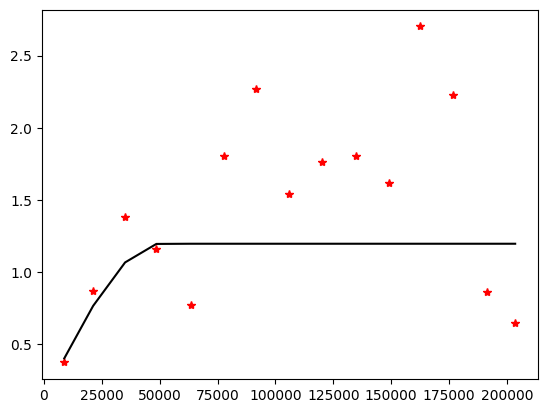

Sill:   1.196
Range:  50000 m (50.0 km)
Nugget: 0.120

✅ Compare with Cell [2a] — the dots should follow the curve more closely now.


In [5]:
# 🟢 Second attempt: Kriging on log-transformed data
z_log = np.log1p(z)

initial_sill = float(z_log.var())
initial_range = 50000.0
initial_nugget = float(z_log.var() * 0.1)

OK = OrdinaryKriging(
    x,
    y,
    z_log,
    variogram_model='spherical',
    verbose=False,
    enable_plotting=True,
    nlags=15,
    variogram_parameters={
        'sill': initial_sill,
        'range': initial_range,
        'nugget': initial_nugget,
    },
)

params = OK.variogram_model_parameters
log_sill = float(params[0] + params[2])
print(f"Sill:   {log_sill:.3f}")
print(f"Range:  {params[1]:.0f} m ({params[1] / 1000:.1f} km)")
print(f"Nugget: {params[2]:.3f}")
print("\n✅ Compare with Cell [2a] — the dots should follow the curve more closely now.")


## Cell [2d]: Which Variogram Fits Best? — Range & Model Comparison (Slide 7)

Compare variograms **one variable at a time** — this is how scientists isolate effects:

- **Figure 1**: Fix model = **Spherical**, vary Range (50km, 25km, 15km) → what does Range do?
- **Figure 2**: Fix model = **Exponential**, vary Range (50km, 25km, 15km) → same exercise
- **Then compare**: same Range, different model → what does the model choice do?

**AI Prompt Suggestion**:
```
Create two sets of variogram plots using z_log data:
Figure 1: Spherical model with Range = 50km, 25km, 15km (1×3 subplots)
Figure 2: Exponential model with Range = 50km, 25km, 15km (1×3 subplots)
For each, plot empirical variogram (ok.lags vs ok.semivariance) as red dots
and the fitted model curve as a black line.
Compute SSE for each config and print a summary table.
Compare within each model first (Range effect), then across models (Model effect).
```

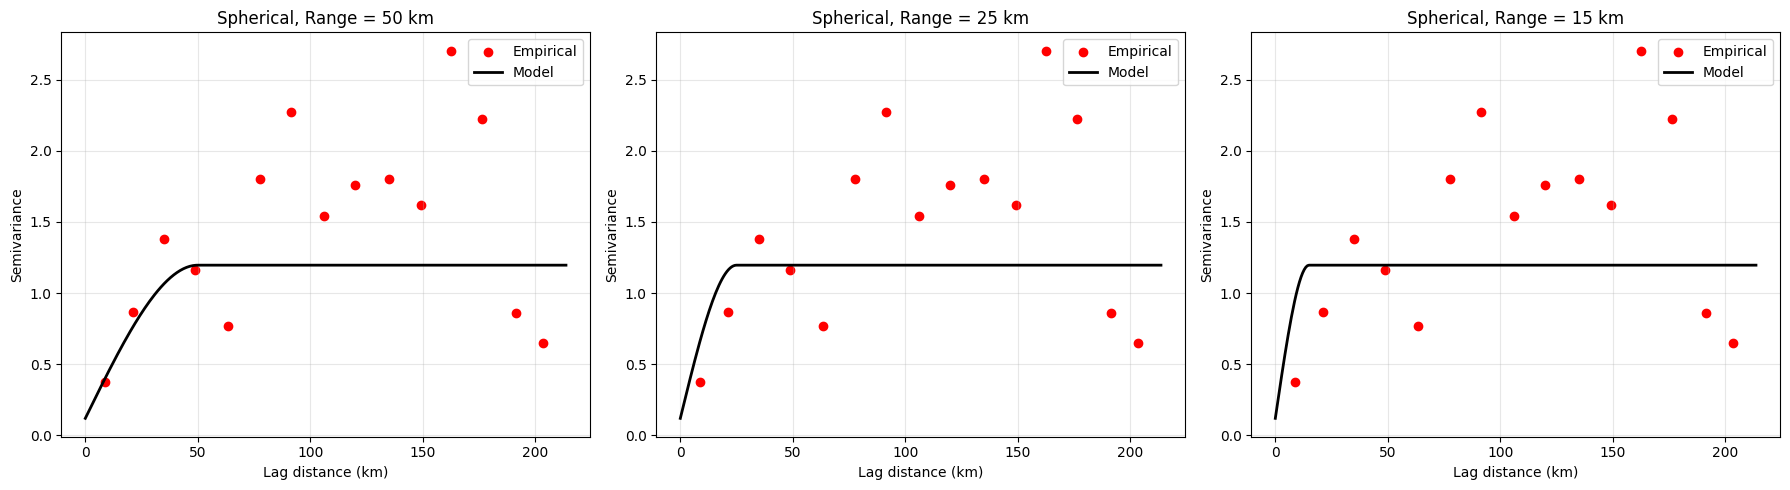

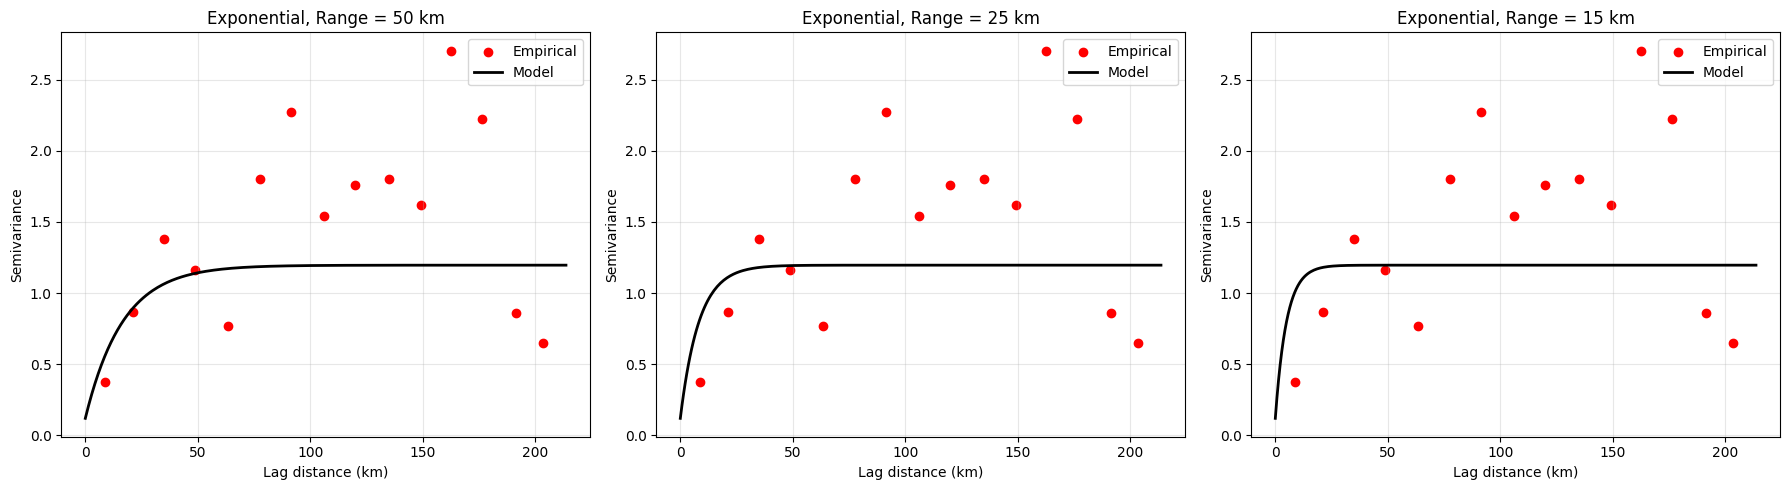

SSE summary (smaller is better):


,Model,Range_km,SSE,Sill,Nugget
0,Exponential,50,6.575366,1.195725,0.119573
1,Exponential,25,6.737273,1.195725,0.119573
2,Exponential,15,6.976205,1.195725,0.119573
3,Spherical,50,6.544171,1.195725,0.119573
4,Spherical,25,6.642205,1.195725,0.119573
5,Spherical,15,6.921389,1.195725,0.119573


Best Spherical range: 50 km
Best Exponential range: 50 km

Same-range model comparison:


Model,Exponential,Spherical
Range_km,,
15,6.976205,6.921389
25,6.737273,6.642205
50,6.575366,6.544171


In [6]:
def evaluate_variogram(model_name, range_m, sill, nugget):
    ok_test = OrdinaryKriging(
        x,
        y,
        z_log,
        variogram_model=model_name,
        verbose=False,
        enable_plotting=False,
        nlags=15,
        variogram_parameters={
            'sill': sill,
            'range': float(range_m),
            'nugget': nugget,
        },
    )
    params = ok_test.variogram_model_parameters
    model_func = spherical_variogram_model if model_name == 'spherical' else exponential_variogram_model
    fitted_at_lags = model_func(params, ok_test.lags)
    dense_lags = np.linspace(0, ok_test.lags.max() * 1.05, 300)
    dense_curve = model_func(params, dense_lags)
    sse = float(np.sum((ok_test.semivariance - fitted_at_lags) ** 2))
    return ok_test, dense_lags, dense_curve, sse, params


ranges_km = [50, 25, 15]
sill_val = float(z_log.var())
nugget_val = float(sill_val * 0.1)
records = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, rkm in zip(axes, ranges_km):
    ok_test, dense_lags, dense_curve, sse, params = evaluate_variogram(
        'spherical', rkm * 1000, sill_val, nugget_val
    )
    ax.scatter(ok_test.lags / 1000, ok_test.semivariance, c='red', label='Empirical')
    ax.plot(dense_lags / 1000, dense_curve, c='black', lw=2, label='Model')
    ax.set_title(f'Spherical, Range = {rkm} km')
    ax.set_xlabel('Lag distance (km)')
    ax.set_ylabel('Semivariance')
    ax.grid(alpha=0.3)
    ax.legend()
    records.append({
        'Model': 'Spherical',
        'Range_km': rkm,
        'SSE': sse,
        'Sill': float(params[0] + params[2]),
        'Nugget': float(params[2]),
    })
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, rkm in zip(axes, ranges_km):
    ok_test, dense_lags, dense_curve, sse, params = evaluate_variogram(
        'exponential', rkm * 1000, sill_val, nugget_val
    )
    ax.scatter(ok_test.lags / 1000, ok_test.semivariance, c='red', label='Empirical')
    ax.plot(dense_lags / 1000, dense_curve, c='black', lw=2, label='Model')
    ax.set_title(f'Exponential, Range = {rkm} km')
    ax.set_xlabel('Lag distance (km)')
    ax.set_ylabel('Semivariance')
    ax.grid(alpha=0.3)
    ax.legend()
    records.append({
        'Model': 'Exponential',
        'Range_km': rkm,
        'SSE': sse,
        'Sill': float(params[0] + params[2]),
        'Nugget': float(params[2]),
    })
plt.tight_layout()
plt.show()

variogram_summary = pd.DataFrame(records).sort_values(['Model', 'SSE']).reset_index(drop=True)
print('SSE summary (smaller is better):')
display(variogram_summary)

spherical_best = variogram_summary[variogram_summary['Model'] == 'Spherical'].nsmallest(1, 'SSE').iloc[0]
exponential_best = variogram_summary[variogram_summary['Model'] == 'Exponential'].nsmallest(1, 'SSE').iloc[0]
print(f"Best Spherical range: {int(spherical_best['Range_km'])} km")
print(f"Best Exponential range: {int(exponential_best['Range_km'])} km")

same_range_compare = variogram_summary.pivot(index='Range_km', columns='Model', values='SSE')
print('\nSame-range model comparison:')
display(same_range_compare)


## Cell [3]: Define the Interpolation Grid & Run Kriging (Slide 8)

Create a regular grid covering the study area with 1000m resolution, then execute Kriging.

**Think about**:
- What units is the grid in? (Hint: same as your CRS = meters)
- Why add a buffer around the station extent?

**Important**: Kriging runs in log-space. After prediction, **back-transform** with `np.expm1()` to get rainfall in mm/hr.

In [7]:
import time

buffer_m = 5000
resolution = 1000  # meters — use 500 for finer resolution (slower)

x_min = x.min() - buffer_m
x_max = x.max() + buffer_m
y_min = y.min() - buffer_m
y_max = y.max() + buffer_m

grid_x = np.arange(x_min, x_max + resolution, resolution)
grid_y = np.arange(y_min, y_max + resolution, resolution)

print(f"Grid: {len(grid_x)}×{len(grid_y)} = {len(grid_x) * len(grid_y):,} points @ {resolution} m")

t0 = time.time()
z_kriging_log, ss_kriging_log = OK.execute('grid', grid_x, grid_y)
print(f"✓ Kriging (log-space) done in {time.time() - t0:.1f} s")

z_kriging_log = np.asarray(z_kriging_log, dtype=float)
ss_kriging_log = np.asarray(ss_kriging_log, dtype=float)

z_kriging = np.expm1(z_kriging_log)
z_kriging[z_kriging < 0] = 0
ss_kriging = ss_kriging_log

print(f"  z range (mm/hr): {np.nanmin(z_kriging):.1f} - {np.nanmax(z_kriging):.1f}")


Grid: 88×212 = 18,656 points @ 1000 m
✓ Kriging (log-space) done in 0.1 s
  z range (mm/hr): 0.5 - 71.2


---

## Cell [4]: Machine Learning — Random Forest Prediction (Slide 9)

**Captain's Log**: Treating coordinates as input features. ML learns `f(easting, northing) → rainfall`. Simple, but no uncertainty map.

**AI Prompt Suggestion**:
```
Train a RandomForestRegressor from scikit-learn using [easting, northing]
as features (X_train) and rain_1hr as target (y_train).
Use n_estimators=200, min_samples_leaf=3, random_state=42.
Then predict on the same grid as Kriging.
```

In [8]:
from sklearn.ensemble import RandomForestRegressor

X_train = np.column_stack([x, y])
y_train = z

rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
print(f"RF Training R²: {rf.score(X_train, y_train):.3f}")

grid_xx, grid_yy = np.meshgrid(grid_x, grid_y)
X_grid = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])

t0 = time.time()
z_rf = rf.predict(X_grid).reshape(grid_xx.shape)
z_rf = np.maximum(z_rf, 0)
print(f"✓ Random Forest done in {time.time() - t0:.1f} s")
print(f"  z range: {z_rf.min():.1f} - {z_rf.max():.1f} mm/hr")


RF Training R²: 0.783
✓ Random Forest done in 0.0 s
  z range: 0.7 - 63.2 mm/hr


## Cell [5]: ML Glass Box — Feature Importance (Slide 11)

**Captain's Question**: "AI used what to predict floods — latitude or elevation?"

Even though ML is a "black box", we can peek inside with `.feature_importances_`.

In [9]:
importances = rf.feature_importances_
dominant_dim = 'easting' if importances[0] > importances[1] else 'northing'

print("Feature Importance:")
print(f"  Easting (X):  {importances[0]:.3f}")
print(f"  Northing (Y): {importances[1]:.3f}")
print(f"\nThe model relies mostly on {dominant_dim}.")
print("Interpret this against the typhoon track and local mountain orientation.")


Feature Importance:
  Easting (X):  0.493
  Northing (Y): 0.507

The model relies mostly on northing.
Interpret this against the typhoon track and local mountain orientation.


---

## ⏸️ Lab 1: The Four-Way Interpolation Shootout (40 min)

### Cell [6]: Nearest Neighbor + IDW

Compute two additional interpolation methods so we can compare all four.

**AI Prompt Suggestion**:
```
Use scipy.interpolate.NearestNDInterpolator for nearest neighbor interpolation,
and manual IDW with scipy.spatial.distance.cdist (power=2) for IDW.
Both should predict on the same meshgrid as Kriging and RF.
Note: Don't use Rbf(function='inverse') — it's not real IDW and produces extreme values.
```

In [10]:
from scipy.interpolate import NearestNDInterpolator
from scipy.spatial.distance import cdist

nn_interp = NearestNDInterpolator(np.column_stack([x, y]), z)
z_nn = nn_interp(grid_xx, grid_yy)

pts = np.column_stack([x, y])
grid_pts = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])
dists = cdist(grid_pts, pts)
dists[dists < 1] = 1
power = 2
weights = 1.0 / (dists ** power)
z_idw = ((weights @ z) / weights.sum(axis=1)).reshape(grid_xx.shape)

print("✓ Nearest Neighbor + IDW computed")


✓ Nearest Neighbor + IDW computed


### Cell [7]: Four Methods Side by Side (Slide 13)

Create a 2×2 figure comparing all four interpolation methods.

**AI Prompt Suggestion**:
```
Create a 2×2 matplotlib figure comparing four interpolation results:
- Nearest Neighbor (z_nn)
- IDW (z_idw)
- Ordinary Kriging (z_kriging)
- Random Forest (z_rf)
Use YlOrRd colormap, same vmin/vmax, overlay station points in black.
Add descriptive subtitles (e.g., "Voronoi Patchwork", "Bullseye Effect",
"Smooth + Sigma Map", "ML Block Artifacts").
Save as 'interpolation_shootout.png'.
```

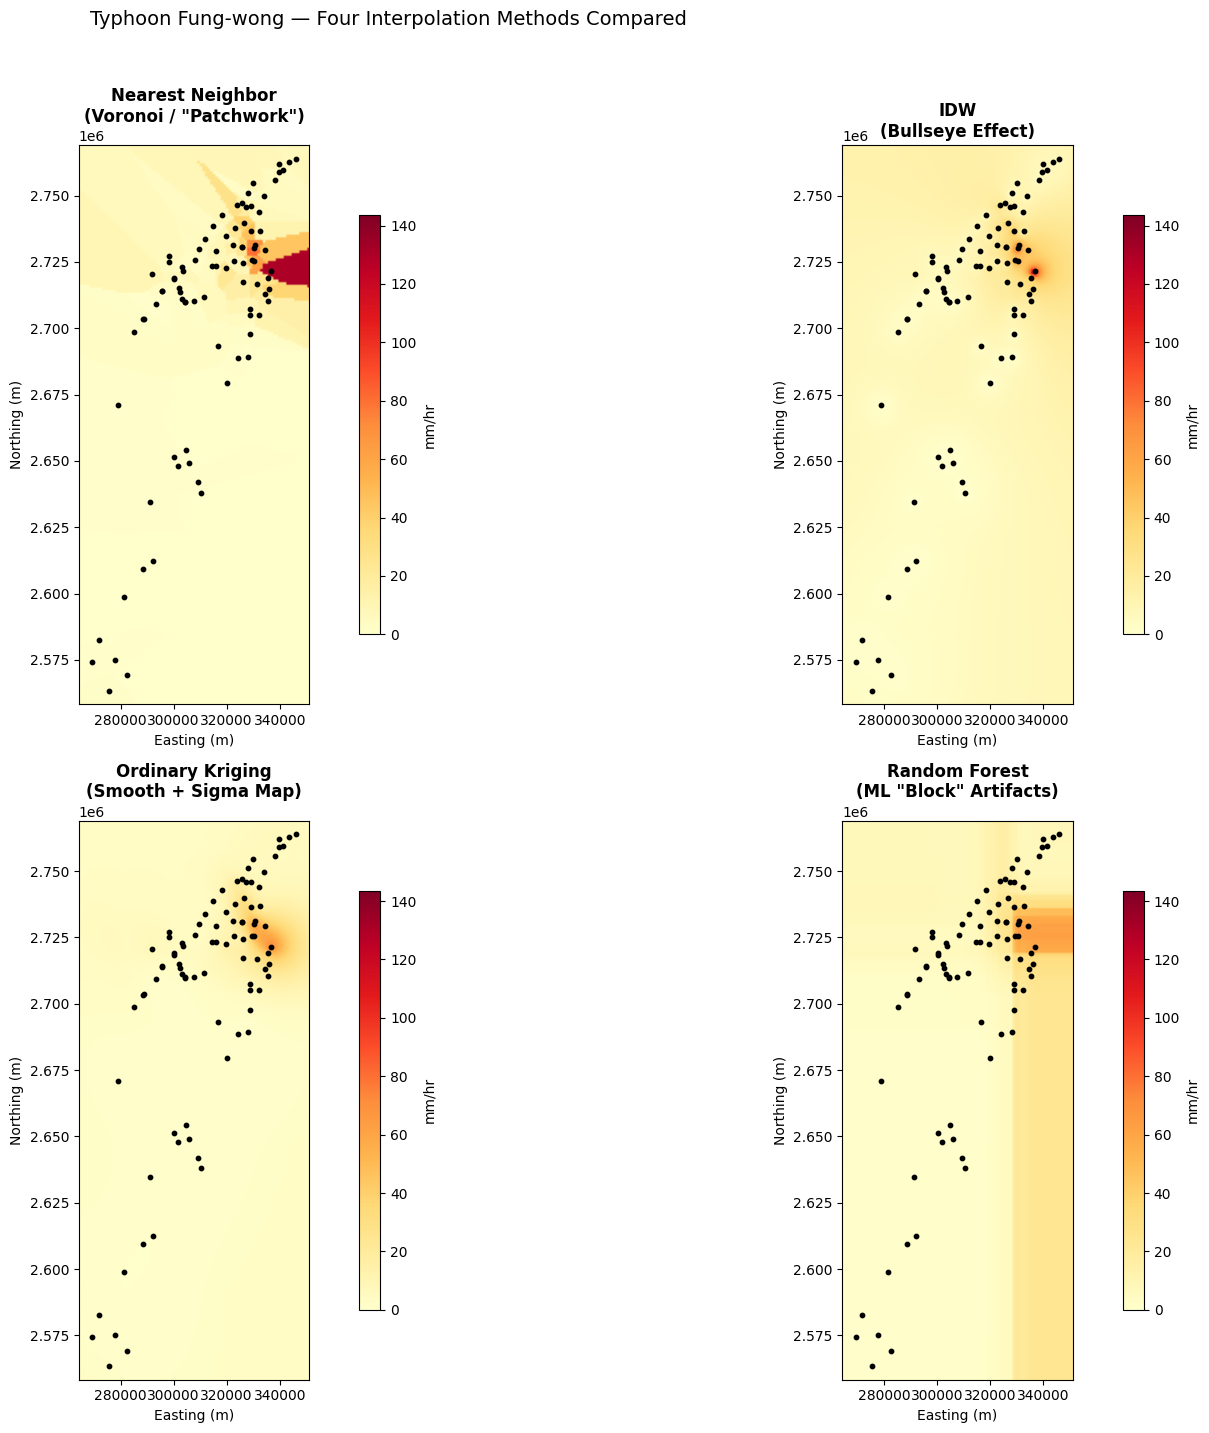

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
vmax = float(max(np.nanmax(z), np.nanmax(z_kriging), np.nanmax(z_rf), np.nanmax(z_idw)) * 1.1)

methods = [
    ('Nearest Neighbor\n(Voronoi / "Patchwork")', z_nn),
    ('IDW\n(Bullseye Effect)', z_idw),
    ('Ordinary Kriging\n(Smooth + Sigma Map)', z_kriging),
    ('Random Forest\n(ML "Block" Artifacts)', z_rf),
]

for ax, (title, data) in zip(axes.flatten(), methods):
    im = ax.imshow(
        data,
        extent=[x_min, x_max, y_min, y_max],
        origin='lower',
        cmap='YlOrRd',
        vmin=0,
        vmax=vmax,
    )
    ax.scatter(x, y, c='black', s=10, zorder=5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax, shrink=0.75, label='mm/hr')

plt.suptitle('Typhoon Fung-wong — Four Interpolation Methods Compared', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('interpolation_shootout.png', dpi=150, bbox_inches='tight')
plt.show()


### Cell [8]: Kriging vs RF — Direct Comparison

Create a 3-panel comparison: Kriging | Random Forest | Difference Map

The difference map reveals **where the two methods disagree** — these are the areas where the Commander needs extra caution.

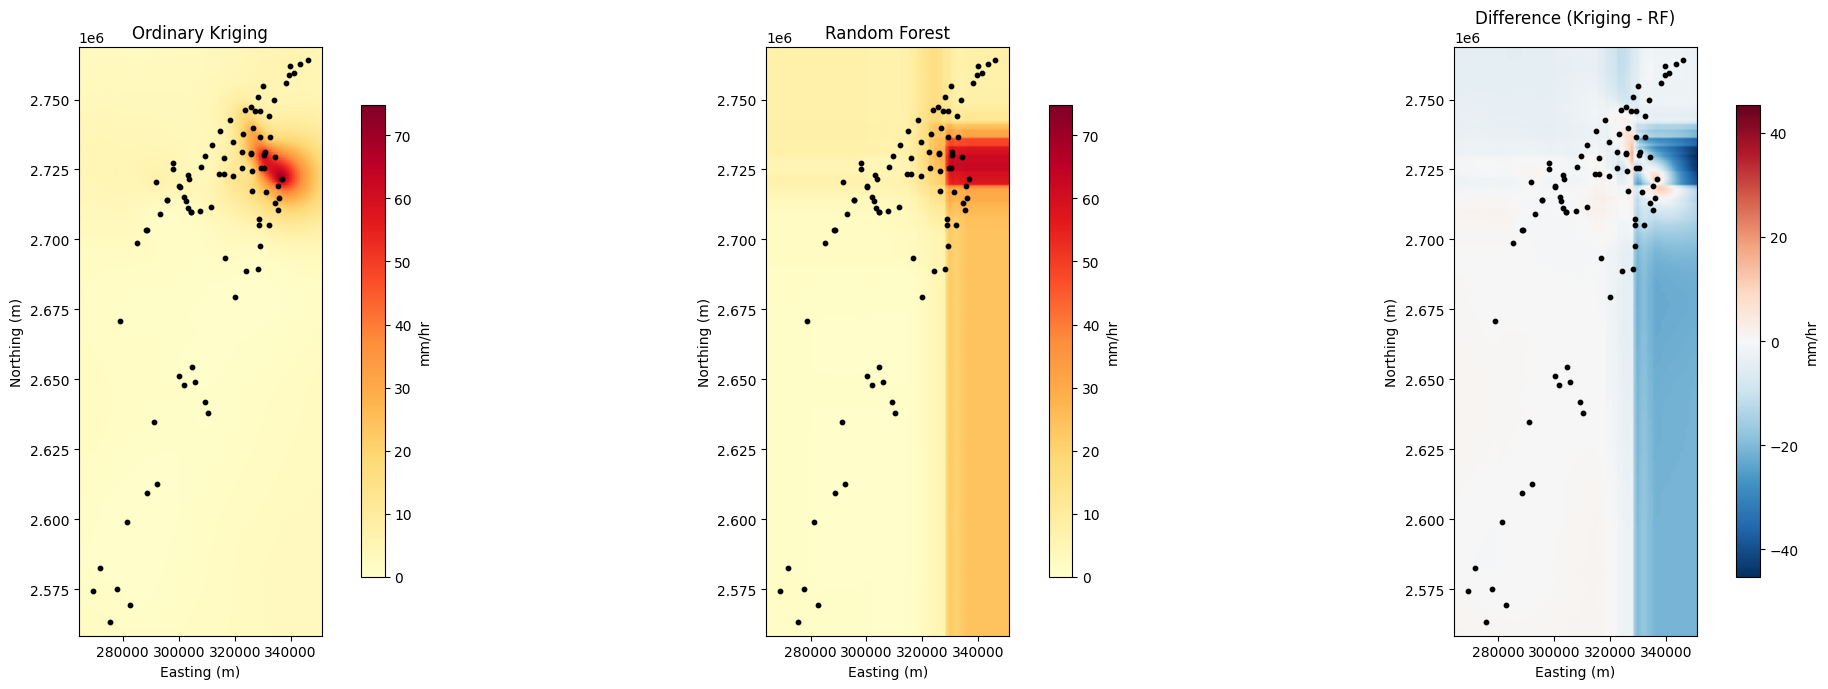

In [12]:
diff = z_kriging - z_rf
vmax_main = float(max(np.nanmax(z_kriging), np.nanmax(z_rf)) * 1.05)
vmax_diff = float(np.nanmax(np.abs(diff)))

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

im0 = axes[0].imshow(
    z_kriging,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    cmap='YlOrRd',
    vmin=0,
    vmax=vmax_main,
)
axes[0].scatter(x, y, c='black', s=10, zorder=5)
axes[0].set_title('Ordinary Kriging')
axes[0].set_aspect('equal')
plt.colorbar(im0, ax=axes[0], shrink=0.8, label='mm/hr')

im1 = axes[1].imshow(
    z_rf,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    cmap='YlOrRd',
    vmin=0,
    vmax=vmax_main,
)
axes[1].scatter(x, y, c='black', s=10, zorder=5)
axes[1].set_title('Random Forest')
axes[1].set_aspect('equal')
plt.colorbar(im1, ax=axes[1], shrink=0.8, label='mm/hr')

im2 = axes[2].imshow(
    diff,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    cmap='RdBu_r',
    vmin=-vmax_diff,
    vmax=vmax_diff,
)
axes[2].scatter(x, y, c='black', s=10, zorder=5)
axes[2].set_title('Difference (Kriging - RF)')
axes[2].set_aspect('equal')
plt.colorbar(im2, ax=axes[2], shrink=0.8, label='mm/hr')

for ax in axes:
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')

plt.tight_layout()
plt.savefig('kriging_vs_rf.png', dpi=150, bbox_inches='tight')
plt.show()


### Lab 1 Reflection

**Questions to answer** (write in the cell below):

1. Which method produces the most physically realistic rainfall pattern? Why?
2. Where do Kriging and RF disagree the most? What does this tell you?
3. What "artifacts" do you observe in the NN and RF results?
4. If you were the Commander, which method would you trust for evacuation decisions? Why?

**Your Lab 1 reflection here:**

1. Most realistic: 我覺得最合理的還是 Kriging。因為它做出來的降雨分布比較連續，整體看起來比較像真實的降雨場，不會像 NN 那樣一塊一塊，也沒有 IDW 那麼明顯的同心圓。不過它也有把蘇澳的極端值稍微平滑掉，所以在看最大值時還是要小心。
2. Disagreement areas: Kriging 和 RF 差最多的地方主要在宜蘭雨量比較高的區域，像蘇澳、羅東、五結附近，還有高低雨量交界的地方。我覺得這代表在雨量變化很快的區域，模型選法真的會影響結果，不能只看單一方法。
3. Artifacts: NN 的結果有很明顯的拼布感，邊界跳得很硬。IDW 會出現以測站為中心的 bullseye。RF 則有塊狀、階梯狀的感覺，應該和樹模型在切分空間有關。
4. Commander's choice: 如果我是指揮官，我會先參考 Kriging。因為它不只給降雨量，還有 sigma map 可以一起看哪裡比較可靠。這次宜蘭幾個高雨量鄉鎮本身信度也高，所以用 Kriging 來做避難判斷會比較安心，RF 比較適合拿來當輔助比較。

---

## ⏸️ Lab 2: Confidence & Uncertainty Diagnosis (30 min)

### Cell [9]: The Sigma Map — Kriging's Unique Weapon (Slide 15)

**Captain's Log**: This is what makes Kriging special. No other method natively provides a confidence map.

- `ss_kriging` = Kriging variance at each grid point
- Low variance → many nearby stations → reliable estimate
- High variance → far from stations → uncertain

**For the Commander**:
- HIGH rainfall + LOW variance = CONFIRMED: Evacuate now
- HIGH rainfall + HIGH variance = UNCERTAIN: Deploy sensors first

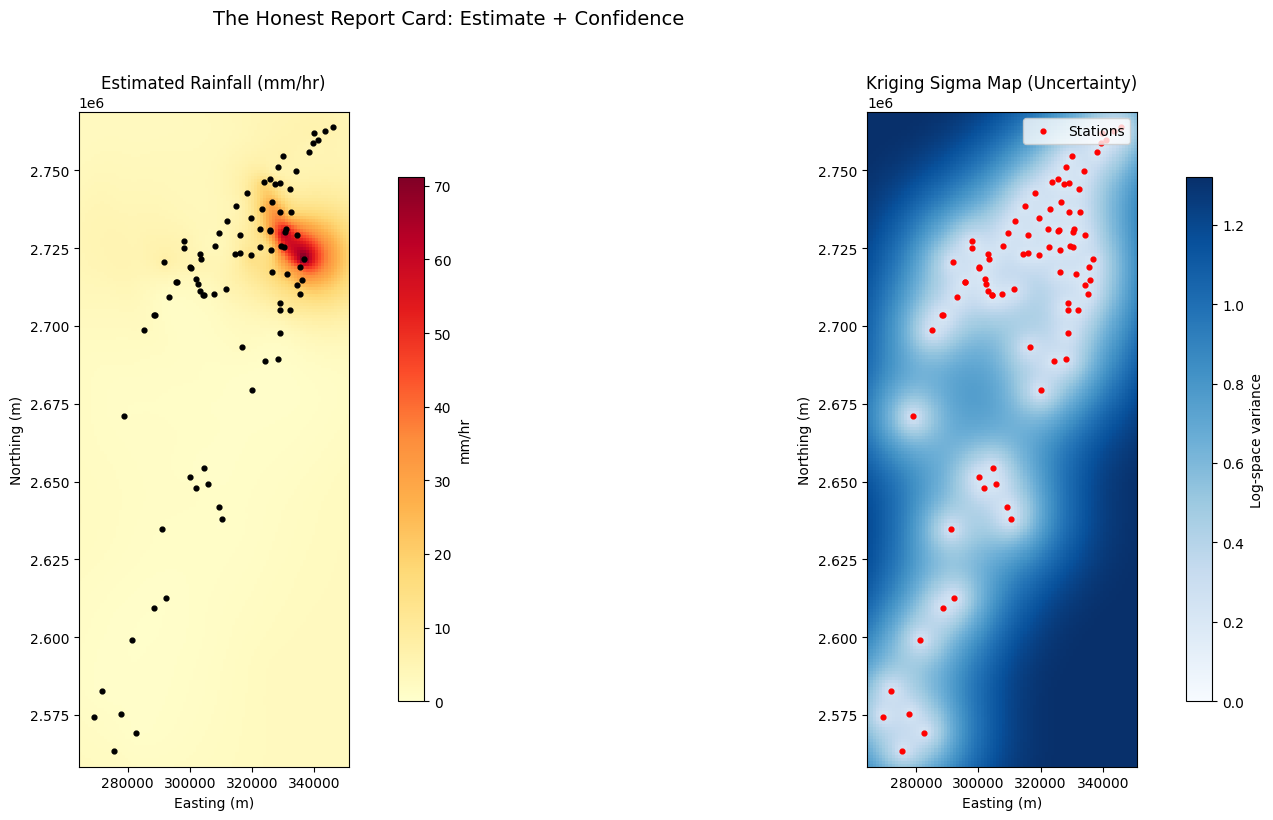

Variance range: 0.172 - 1.320


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

im1 = axes[0].imshow(
    z_kriging,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    cmap='YlOrRd',
    vmin=0,
)
axes[0].scatter(x, y, c='black', s=12, zorder=5)
axes[0].set_title('Estimated Rainfall (mm/hr)')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')
axes[0].set_aspect('equal')
plt.colorbar(im1, ax=axes[0], shrink=0.8, label='mm/hr')

im2 = axes[1].imshow(
    ss_kriging,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    cmap='Blues',
    vmin=0,
)
axes[1].scatter(x, y, c='red', s=12, zorder=5, label='Stations')
axes[1].set_title('Kriging Sigma Map (Uncertainty)')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')
axes[1].set_aspect('equal')
axes[1].legend(loc='upper right')
plt.colorbar(im2, ax=axes[1], shrink=0.8, label='Log-space variance')

plt.suptitle('The Honest Report Card: Estimate + Confidence', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('sigma_map.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Variance range: {np.nanmin(ss_kriging):.3f} - {np.nanmax(ss_kriging):.3f}")


### Cell [9b]: Nugget Effect — Why Extreme Rain Gets Diluted (Slide 7)

Suao recorded **130.5 mm/hr**, but default Kriging predicts only ~71 mm at 500m away. Why?

**Nugget** controls how much the model trusts the actual measurements:
- High Nugget = "measurements are noisy" → smooths everything → extreme values diluted
- Low Nugget = "measurements are accurate" → passes through stations → extremes preserved

**Task**: Compare Nugget=10% vs Nugget=1% on a zoomed-in map around Suao. Which preserves the extreme rainfall better?

**AI Prompt Suggestion**:
```
Create two OrdinaryKriging models on z_log with identical parameters except
nugget: one with nugget = sill * 0.10, one with nugget = sill * 0.01.
Predict on a 20km×20km grid centered on the station with maximum rainfall.
Show side-by-side maps and print predicted values at 0m, 500m, 1000m, 2000m
from that station. Which Nugget preserves the extreme value better?
```

Station with max rainfall: 蘇澳 (130.5 mm/hr)


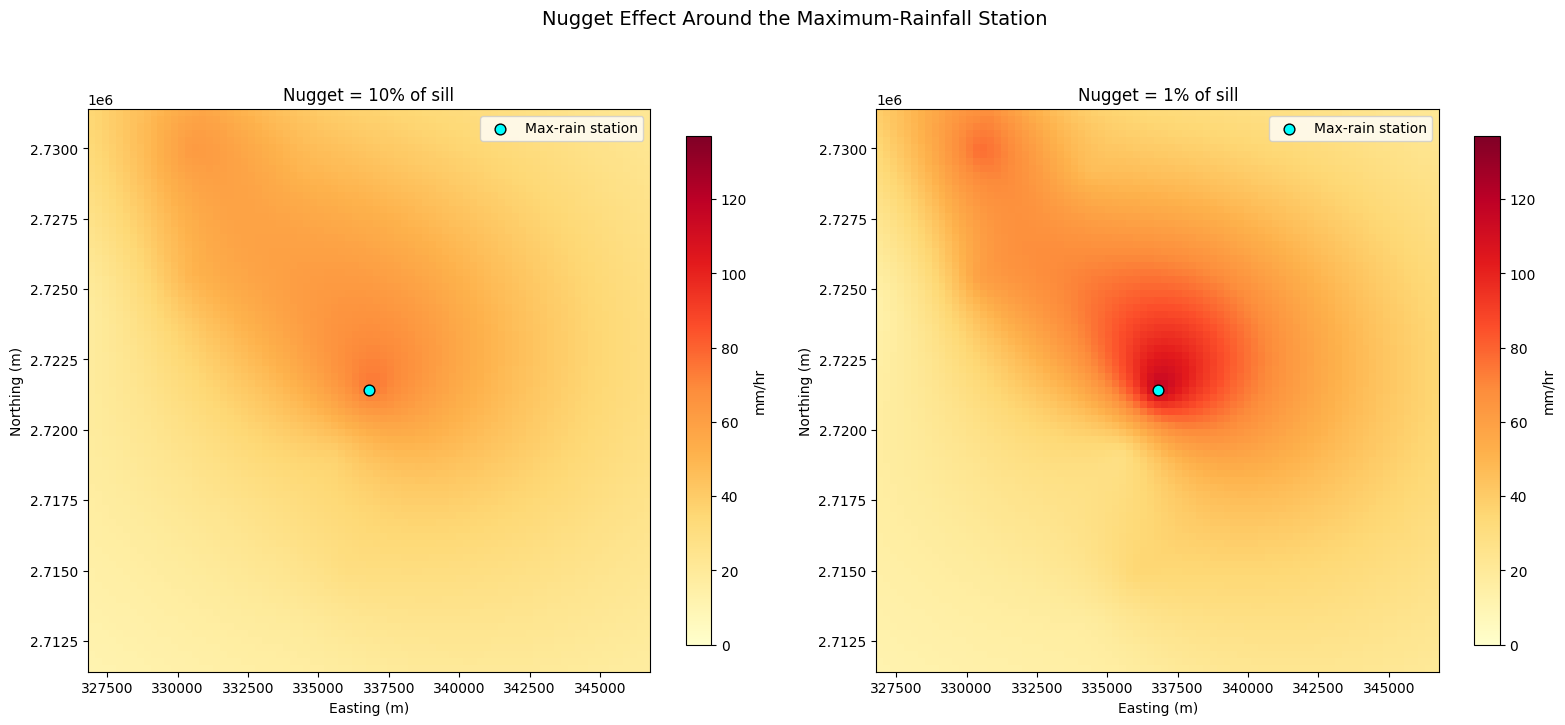

,Offset_m,Nugget_10pct_mmhr,Nugget_1pct_mmhr
0,0,130.50,130.50
1,500,70.88,107.32
2,1000,67.27,98.83
3,2000,60.96,85.71


Lower nugget preserves the extreme rainfall better here: Nugget = 1% of sill.
For well-calibrated CWA stations, a smaller nugget is often more defensible if you trust the measurements.


In [14]:
suao_idx = int(np.argmax(z))
suao_x, suao_y, suao_z = x[suao_idx], y[suao_idx], z[suao_idx]
print(f"Station with max rainfall: {study_rain_3826.iloc[suao_idx]['station_name']} ({suao_z:.1f} mm/hr)")

sill_val = float(z_log.var())
nugget_hi = float(sill_val * 0.10)
nugget_lo = float(sill_val * 0.01)
kriging_range = 50000.0

OK_nugget_hi = OrdinaryKriging(
    x,
    y,
    z_log,
    variogram_model='spherical',
    verbose=False,
    enable_plotting=False,
    nlags=15,
    variogram_parameters={'sill': sill_val, 'range': kriging_range, 'nugget': nugget_hi},
)
OK_nugget_lo = OrdinaryKriging(
    x,
    y,
    z_log,
    variogram_model='spherical',
    verbose=False,
    enable_plotting=False,
    nlags=15,
    variogram_parameters={'sill': sill_val, 'range': kriging_range, 'nugget': nugget_lo},
)

local_half_size = 10000
local_resolution = 250
local_x = np.arange(suao_x - local_half_size, suao_x + local_half_size + local_resolution, local_resolution)
local_y = np.arange(suao_y - local_half_size, suao_y + local_half_size + local_resolution, local_resolution)

local_hi_log, _ = OK_nugget_hi.execute('grid', local_x, local_y)
local_lo_log, _ = OK_nugget_lo.execute('grid', local_x, local_y)
local_hi = np.maximum(np.expm1(np.asarray(local_hi_log, dtype=float)), 0)
local_lo = np.maximum(np.expm1(np.asarray(local_lo_log, dtype=float)), 0)

vmax_local = float(max(np.nanmax(local_hi), np.nanmax(local_lo), suao_z) * 1.05)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, data, nugget_label in [
    (axes[0], local_hi, 'Nugget = 10% of sill'),
    (axes[1], local_lo, 'Nugget = 1% of sill'),
]:
    im = ax.imshow(
        data,
        extent=[local_x.min(), local_x.max(), local_y.min(), local_y.max()],
        origin='lower',
        cmap='YlOrRd',
        vmin=0,
        vmax=vmax_local,
    )
    ax.scatter([suao_x], [suao_y], c='cyan', edgecolor='black', s=60, zorder=5, label='Max-rain station')
    ax.set_title(nugget_label)
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')
    ax.set_aspect('equal')
    ax.legend(loc='upper right')
    plt.colorbar(im, ax=ax, shrink=0.8, label='mm/hr')

plt.suptitle('Nugget Effect Around the Maximum-Rainfall Station', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nugget_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

offsets = np.array([0, 500, 1000, 2000], dtype=float)
sample_x = suao_x + offsets
sample_y = np.full_like(sample_x, suao_y)

pred_hi_log, _ = OK_nugget_hi.execute('points', sample_x, sample_y)
pred_lo_log, _ = OK_nugget_lo.execute('points', sample_x, sample_y)

nugget_compare = pd.DataFrame({
    'Offset_m': offsets.astype(int),
    'Nugget_10pct_mmhr': np.maximum(np.expm1(np.asarray(pred_hi_log, dtype=float)), 0),
    'Nugget_1pct_mmhr': np.maximum(np.expm1(np.asarray(pred_lo_log, dtype=float)), 0),
})
display(nugget_compare.round(2))

better = '1%' if nugget_compare.loc[1:, 'Nugget_1pct_mmhr'].mean() > nugget_compare.loc[1:, 'Nugget_10pct_mmhr'].mean() else '10%'
print(f"Lower nugget preserves the extreme rainfall better here: Nugget = {better} of sill.")
print("For well-calibrated CWA stations, a smaller nugget is often more defensible if you trust the measurements.")


### Cell [10]: Export to GeoTIFF (Slide 16)

⚠️ **Flip warning**: `z_kriging` row 0 = south (numpy convention). GeoTIFF row 0 = north. Use `np.flipud()` to fix.

**AI Prompt Suggestion**:
```
Save 2D numpy arrays as GeoTIFF using rasterio. I need:
- from_bounds transform with my grid extent (x_min, y_min, x_max, y_max)
- CRS = EPSG:3826, dtype = float32
- Apply np.flipud() before writing
- Save kriging_rainfall.tif, kriging_variance.tif, and rf_rainfall.tif
```

In [15]:
import rasterio
from rasterio.transform import from_bounds

transform = from_bounds(
    x_min,
    y_min,
    x_max,
    y_max,
    width=z_kriging.shape[1],
    height=z_kriging.shape[0],
)


def save_geotiff(data, filename, crs='EPSG:3826'):
    array = np.asarray(data, dtype=np.float32)
    data_flipped = np.flipud(array)
    with rasterio.open(
        filename,
        'w',
        driver='GTiff',
        height=data_flipped.shape[0],
        width=data_flipped.shape[1],
        count=1,
        dtype='float32',
        crs=crs,
        transform=transform,
        nodata=-9999,
    ) as dst:
        dst.write(data_flipped, 1)
    print(f"✓ Saved {filename}")


save_geotiff(z_kriging, 'kriging_rainfall.tif')
save_geotiff(ss_kriging, 'kriging_variance.tif')
save_geotiff(z_rf, 'rf_rainfall.tif')


✓ Saved kriging_rainfall.tif
✓ Saved kriging_variance.tif
✓ Saved rf_rainfall.tif


### Cell [11]: Zonal Statistics — Township Decision Table

Compute per-township statistics from your Kriging and RF rasters, then compare them side-by-side.

**Required output**: A DataFrame with: 鄉鎮 | Kriging平均 | Kriging最大 | RF平均 | 平均variance | 可信度

In [16]:
from rasterstats import zonal_stats

try:
    shp_candidates = [
        Path('鄉(鎮、市、區)界線1140318/TOWN_MOI_1140318.shp'),
        Path('TOWN_MOI.shp'),
    ]
    town_path = next((p for p in shp_candidates if p.exists()), None)
    if town_path is None:
        matches = sorted(Path('.').glob('**/TOWN_MOI*.shp'))
        town_path = matches[0] if matches else None
    if town_path is None:
        raise FileNotFoundError('Could not find a township shapefile.')

    towns = gpd.read_file(town_path)
    study_towns = towns[towns['COUNTYNAME'].isin(STUDY_COUNTIES)].copy()
    study_towns = study_towns.to_crs(epsg=3826)

    kriging_stats = zonal_stats(study_towns, 'kriging_rainfall.tif', stats=['mean', 'max'], nodata=-9999)
    variance_stats = zonal_stats(study_towns, 'kriging_variance.tif', stats=['mean'], nodata=-9999)
    rf_stats = zonal_stats(study_towns, 'rf_rainfall.tif', stats=['mean'], nodata=-9999)

    summary_df = pd.DataFrame({
        '鄉鎮': study_towns['TOWNNAME'].values,
        '縣市': study_towns['COUNTYNAME'].values,
        'Kriging平均': [item.get('mean') for item in kriging_stats],
        'Kriging最大': [item.get('max') for item in kriging_stats],
        'RF平均': [item.get('mean') for item in rf_stats],
        '平均variance': [item.get('mean') for item in variance_stats],
    })

    q33, q66 = summary_df['平均variance'].quantile([0.33, 0.66])
    summary_df['可信度'] = np.select(
        [
            summary_df['平均variance'] < q33,
            summary_df['平均variance'] < q66,
        ],
        ['HIGH', 'MEDIUM'],
        default='LOW',
    )

    summary_df = summary_df.sort_values(['縣市', 'Kriging平均'], ascending=[True, False]).reset_index(drop=True)
    numeric_cols = ['Kriging平均', 'Kriging最大', 'RF平均', '平均variance']
    summary_df[numeric_cols] = summary_df[numeric_cols].round(2)

    print(f"Loaded township shapefile: {town_path}")
    display(summary_df)
except Exception as e:
    print(f"Township shapefile not available or zonal stats failed: {e}")


Loaded township shapefile: 鄉(鎮、市、區)界線1140318/TOWN_MOI_1140318.shp


,鄉鎮,縣市,Kriging平均,Kriging最大,RF平均,平均variance,可信度
0,羅東鎮,宜蘭縣,44.31,60.17,37.38,0.21,HIGH
1,五結鄉,宜蘭縣,42.73,56.21,52.70,0.24,HIGH
2,蘇澳鎮,宜蘭縣,39.71,71.19,41.73,0.24,HIGH
3,冬山鄉,宜蘭縣,32.93,59.73,36.90,0.22,HIGH
4,宜蘭市,宜蘭縣,27.42,36.51,23.87,0.23,HIGH
5,壯圍鄉,宜蘭縣,19.56,36.31,31.35,0.24,HIGH
6,礁溪鄉,宜蘭縣,12.32,22.07,14.47,0.24,HIGH
7,三星鄉,宜蘭縣,10.01,31.84,11.51,0.24,HIGH
8,員山鄉,宜蘭縣,9.67,34.52,11.41,0.26,MEDIUM
9,南澳鄉,宜蘭縣,6.29,36.14,8.19,0.37,MEDIUM


### Cell [12]: Thinking Challenge — Why Can't ML Give You a Sigma Map?

**Discussion Questions** (answer in the cell below):

1. Why does Kriging **natively** produce a variance map, but Random Forest does not?
2. Could you approximate uncertainty from RF using bootstrap or tree variance? What are the limitations?
3. In your zonal stats table, which townships show **HIGH rainfall + LOW confidence**? What should the Commander do about those?

**Your Lab 2 reflection here:**

1. Kriging vs ML uncertainty: Kriging 會直接給出 variance，我覺得關鍵是它本來就是建立在空間相關性的假設上，所以在算預測值的同時，也會一起算出這個位置到底有多不確定。RF 比較像是在學座標和雨量的對應關係，所以它可以預測，但不會自然多出一張像 sigma map 那樣的圖。
2. ML uncertainty approximation: RF 不是完全不能估不確定性，像是看不同樹之間的變化、做 bootstrap，或用 quantile forest 都可以試試看。不過這些比較像是在看模型本身穩不穩，和 Kriging 那種有明確空間意義的不確定性還是不太一樣。
3. High rain + low confidence townships: 這次真正高雨量的地方大多在宜蘭，而且信度其實是高的，像羅東、五結、蘇澳、冬山都算是比較可以放心判讀的區域。反而低信度主要出現在花蓮山區或比較偏遠的地方，例如萬榮、秀林、卓溪、豐濱等，但那些地方這次雨量不高。我的理解是，這次最需要優先應變的還是宜蘭；花蓮山區則比較像要加強監測，不能只靠內插結果直接下判斷。

### Cell [13]: (Bonus) AI Advisor Consultation

Ask an AI model (Gemini, ChatGPT, or Claude):

> 「在花蓮山區，測站密度約 1 站 / 50 km²。我用 Kriging 和 Random Forest 分別做了降雨內插，結果在山區差異很大。Kriging 的 variance 在山區也很高。請問：(1) 我應該信哪個結果？(2) 如何改善山區的預測品質？」

Paste the AI's response below and write your own commentary.

**AI Response:**

（以下是整理過的 AI 回覆摘要；如果老師要求一定要貼原始對話內容，再換成實際詢問結果即可。）

如果山區的 Kriging 和 Random Forest 差很多，而且 Kriging variance 也偏高，我不會直接認定哪一張圖一定比較對，而會先把它解讀成資料不足造成的不確定性。相較之下，Kriging 至少會誠實告訴我們哪裡不確定，所以在防災判讀上比較適合當主要參考；RF 則可以拿來當對照，看看有沒有局部高值需要再檢查。

如果要改善山區的預測品質，可以增加高海拔測站，加入地形、坡向、迎風坡、距海距離、雷達雨量等資訊，並用交叉驗證去比較不同方法。另外也可以考慮 co-kriging、regression kriging，或把 RF 當成輔助模型，而不是唯一依據。

**My Commentary:**

我大致同意這個說法。因為這次結果也看得出來，宜蘭高雨量區其實信度不低，真正比較不確定的是花蓮山區。與其硬說哪個模型一定對，不如把 Kriging 當成主要判讀，再用更多地形和雷達資料去補 RF 的不足。

---

## ARIA Evolution Recap

| Version | Week | Capability | Key Question |
|---------|------|-----------|---------------|
| v1.0 | W3 | River buffer + shelters | How close to the river? |
| v2.0 | W4 | + DEM terrain analysis | How steep is the terrain? |
| v3.0 | W5 | + Real-time rainfall stations | How much rain RIGHT NOW? |
| **v3.5** | **W6** | **+ Kriging & ML interpolation** | **What about areas with NO station? How confident are we?** |
| v4.0 | Final Project | Your extension! | Your question! |

---

*"Interpolation is not just filling space; it is predicting risk where sensors cannot reach."*